# Notebook 3 - The Watchlist 

This notebook turns the XGBoost out-of-fold probabilities into one of the project's  deliverables: a ranked watchlist of undesignated planning areas that most resemble Milieuschutz-designated ones. 

Working from the out-of-fold scores keeps every ranking honest, since each area was scored by a model that never saw its own district. After restricting to undesignated areas (y_true = 0), the distribution of scores is inspected to find a provisional cutoff point until the cleanlab library validates the prediction outcome. The shortlist is then mapped across Berlin. 

As throughout Module 2, the score expresses similarity to the existing designation pattern, not an objective probability of displacement. The undesignated areas surfacing near the top are precisely the early-warning candidates the platform is built to find.


In [1]:
#load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap


In [2]:
#load the XGBoost OOF probabilities set 
xgb_oof = pd.read_csv("../../models/M_oof_xgboost.csv", dtype={"plr_id": str})

#load dataset_0 for readable identifiers (plr_name, bez)
meta = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})
meta = meta[["plr_id", "plr_name", "bez"]]

#zero-pad plr_id consistently (same convention as NB1/NB2)
for d in (xgb_oof, meta):   
    d["plr_id"] = d["plr_id"].astype(str).str.zfill(8)

#build the working table: XGBoost oof_prob + labels + names/district
df = xgb_oof.merge(meta, on="plr_id", how="left")

#sanity 
assert df["plr_name"].notna().all(), "some PLR did not get a name/district — check the merge"
assert len(df) == len(xgb_oof), "merge changed row count — duplicate plr_id?"
print(f"{len(df)} PLR | {int(df['y_true'].sum())} designated | "
      f"{int((df['y_true']==0).sum())} undesignated")

527 PLR | 109 designated | 418 undesignated


### Finding a provisional Threshold for the Watchlist

To turn a continuous ranking into a finite shortlist, the out-of-fold probabilities of the undesignated areas are inspected to look for a potential break. 


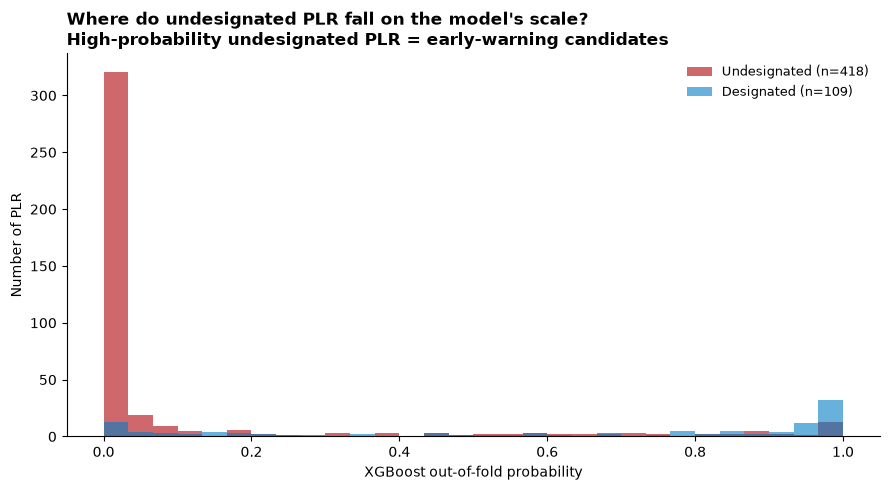

      plr_id                plr_name                              bez  oof_prob
0   01401044              Uferstraße                       01 - Mitte  0.999109
1   01300731           Koloniestraße                       01 - Mitte  0.997601
2   01100416             Arkonaplatz                       01 - Mitte  0.995976
3   07100206      Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505
4   01200623             Stephankiez                       01 - Mitte  0.986148
5   01401049             Schulstraße                       01 - Mitte  0.985959
6   04501147       Leon-Jessel-Platz  04 - Charlottenburg-Wilmersdorf  0.984600
7   01300836   Humboldthain Nordwest                       01 - Mitte  0.984006
8   01200522      Elberfelder Straße                       01 - Mitte  0.983263
9   01200628       Lüneburger Straße                       01 - Mitte  0.979387
10  09200511       Griechischer Park            09 - Treptow-Köpenick  0.977478
11  01300834           Brunnenstraße    

In [3]:
#Distribution of XGBoost oof_prob, split by actual designation status
#Goal: where do undesignated PLR sit? Is there a natural cutoff for the watchlist that can be used?
desig   = df.loc[df["y_true"] == 1, "oof_prob"]
undesig = df.loc[df["y_true"] == 0, "oof_prob"]

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, 1, 31)
ax.hist(undesig, bins=bins, alpha=0.6, color="#AE030C", label=f"Undesignated (n={len(undesig)})")
ax.hist(desig,   bins=bins, alpha=0.6, color="#027DC5", label=f"Designated (n={len(desig)})")
ax.set_xlabel("XGBoost out-of-fold probability", fontsize=10)
ax.set_ylabel("Number of PLR", fontsize=10)
ax.set_title("Where do undesignated PLR fall on the model's scale?\n"
             "High-probability undesignated PLR = early-warning candidates",
             fontsize=12, fontweight="bold", loc="left")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

#eyeball the top undesignated PLR to see where probabilities start dropping
top_undesig = (df[df["y_true"] == 0]
               .sort_values("oof_prob", ascending=False)
               [["plr_id", "plr_name", "bez", "oof_prob"]]
               .head(30)
               .reset_index(drop=True))
print(top_undesig.to_string())

### Result: Threshold

The scores fall off gradually, but a visible step appears after the 25th-ranked area (oof_prob 0.824 → 0.767), which could be used as a pragmatic cutoff. For the time being, this is the cut-off point to be adopted. After the validation of cleanlab library is done, this might be changed. 

## Ranking Prediction Outcome - the Watchlist 

The out-of-fold probabilities are turned into an actionable shortlist by keeping only undesignated planning areas (milieu_anteil below the majority threshold) and ranking them by how strongly the model rates them as designation-like. A provisional cut at the 25 highest-ranked areas is taken here, at the visible probability drop after rank 25 (0.824 → 0.767). 

This length is revisited in NB4, where the Cleanlab validation determines the final watchlist size.

In [ ]:
#Cutoff N=25, provisionally chosen for now at the visible probability drop (0.824 -> 0.767 after rank 25)

N_LIST = 25

watchlist25 = (
    df[df["y_true"] == 0]
    .sort_values("oof_prob", ascending=False)
    .head(N_LIST)
    .reset_index(drop=True)
    [["plr_id", "plr_name", "bez", "oof_prob"]]
)
watchlist25.index = watchlist25.index + 1
watchlist25.index.name = "rank"

cutoff_in  = watchlist25["oof_prob"].iloc[-1]
first_out  = (df[df["y_true"] == 0]
              .sort_values("oof_prob", ascending=False)["oof_prob"].iloc[N_LIST])
print(f"Resemblance List: {N_LIST} undesignated PLR (pure oof_prob ranking)")
print(f"Cutoff: last included oof_prob = {cutoff_in:.3f} | first excluded = {first_out:.3f}")
print(f"District distribution:\n{watchlist25['bez'].value_counts().to_string()}")
print()
print(watchlist25.to_string())

#export the watchlist (to be validated by cleanlab in NB4)
watchlist25_out = watchlist25.reset_index()
watchlist25_out.to_csv("../../models/M2_watchlist.csv", index=False)
print(f"\nexported {len(watchlist25_out)} PLR -> M2_watchlist.csv")



Resemblance List: 25 undesignated PLR (pure oof_prob ranking)
Cutoff: last included oof_prob = 0.824 | first excluded = 0.767
District distribution:
bez
01 - Mitte                         12
04 - Charlottenburg-Wilmersdorf     4
07 - Tempelhof-Schöneberg           3
09 - Treptow-Köpenick               2
02 - Friedrichshain-Kreuzberg       1
03 - Pankow                         1
08 - Neukölln                       1
12 - Reinickendorf                  1

        plr_id                plr_name                              bez  oof_prob
rank                                                                             
1     01401044              Uferstraße                       01 - Mitte  0.999109
2     01300731           Koloniestraße                       01 - Mitte  0.997601
3     01100416             Arkonaplatz                       01 - Mitte  0.995976
4     07100206      Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505
5     01200623             Stephankiez            

## Result Discussion: the Prediction Outcome 

The 25 highest-ranked undesignated areas concentrate heavily in Mitte (12 of 25), with the remainder spread across Charlottenburg-Wilmersdorf, Tempelhof-Schöneberg and six other districts. Thats an inner-city clustering consistent with the early-warning thesis. 



## Ab hier Watchlist of 38 in NB5, after validation of Cleanlab 

erklären was gemacht. 

In [6]:
#Cutoff N=38, after cleanlab validation, a new cutoff point of 38 PLRs is chosen 

N_LIST = 38

watchlist38 = (
    df[df["y_true"] == 0]
    .sort_values("oof_prob", ascending=False)
    .head(N_LIST)
    .reset_index(drop=True)
    [["plr_id", "plr_name", "bez", "oof_prob"]]
)
watchlist38.index = watchlist38.index + 1
watchlist38.index.name = "rank"

cutoff_in  = watchlist38["oof_prob"].iloc[-1]
first_out  = (df[df["y_true"] == 0]
              .sort_values("oof_prob", ascending=False)["oof_prob"].iloc[N_LIST])
print(f"Resemblance List: {N_LIST} undesignated PLR (pure oof_prob ranking)")
print(f"Cutoff: last included oof_prob = {cutoff_in:.3f} | first excluded = {first_out:.3f}")
print(f"District distribution:\n{watchlist38['bez'].value_counts().to_string()}")
print()
print(watchlist38.to_string())

#export the watchlist38
watchlist38_out = watchlist38.reset_index()
watchlist38_out.to_csv("../../models/M2_watchlist38.csv", index=False)
print(f"\nexported {len(watchlist38_out)} PLR -> M2_watchlist38.csv")



Resemblance List: 38 undesignated PLR (pure oof_prob ranking)
Cutoff: last included oof_prob = 0.586 | first excluded = 0.575
District distribution:
bez
01 - Mitte                         15
04 - Charlottenburg-Wilmersdorf     8
09 - Treptow-Köpenick               4
07 - Tempelhof-Schöneberg           3
12 - Reinickendorf                  3
08 - Neukölln                       2
02 - Friedrichshain-Kreuzberg       1
03 - Pankow                         1
05 - Spandau                        1

        plr_id                plr_name                              bez  oof_prob
rank                                                                             
1     01401044              Uferstraße                       01 - Mitte  0.999109
2     01300731           Koloniestraße                       01 - Mitte  0.997601
3     01100416             Arkonaplatz                       01 - Mitte  0.995976
4     07100206      Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505
5     012006

## How to know whether those are artefacts in Charlottenburg-Wilmersdorf? 

„8 der 38 liegen in Charlottenburg-Wilmersdorf, dem schwachen CV-Fold; die höher gerankten davon (Leon-Jessel-Platz, Schloßstraße) sind trotz des schwachen Folds belastbar, während die vier am unteren Listenende mit niedrigeren Scores mit entsprechender Vorsicht zu lesen sind."

## A Map of Berlin - the Watchlist

The watchlist is mapped across all 542 planning areas to see where the look-alike candidates sit spatially. Undesignated areas are shaded by their model score; already-designated and non-modelled areas (the 15 low-density PLR excluded from dataset_0) are left grey. 

The map is read as a similarity surface, not a probability of displacement.

In [7]:
gdf = gpd.read_file("../../data/real_estate/Geodata/PLR_raw.geojson")
gdf["plr_id"] = gdf["plr_id"].astype(str).str.zfill(8)

print("Spalten:", gdf.columns.tolist())
print("CRS:", gdf.crs)
print("Zeilen:", len(gdf))
print(gdf.drop(columns="geometry").head(3).to_string())

Spalten: ['id', 'plr_id', 'plr_name', 'bzr_id', 'bzr_name', 'pgr_id', 'pgr_name', 'bez', 'finhalt', 'stadtraum_id', 'stadtraum_name', 'stand', 'geometry']
CRS: EPSG:25833
Zeilen: 542
                        id    plr_id           plr_name  bzr_id        bzr_name pgr_id pgr_name         bez       finhalt stadtraum_id stadtraum_name       stand
0  a_lor_plr_2021.01100101  01100101       Stülerstraße  011001  Tiergarten Süd   0110  Zentrum  01 - Mitte  3.669331e+05            1   Innere Stadt  01.01.2021
1  a_lor_plr_2021.01100102  01100102  Großer Tiergarten  011001  Tiergarten Süd   0110  Zentrum  01 - Mitte  3.919852e+06            1   Innere Stadt  01.12.2021
2  a_lor_plr_2021.01100103  01100103       Lützowstraße  011001  Tiergarten Süd   0110  Zentrum  01 - Mitte  5.471832e+05            1   Innere Stadt  01.12.2021


In [ ]:
#Merge model output onto PLR geometries; milieu_anteil pulled in SEPARATELY (interpretation only, never a feature)
#labels_full holds milieu_anteil (from target_milieuschutz.csv) — kept out of df on purpose

milieu = (pd.read_csv("../../data/Module 2/target_milieuschutz.csv", dtype={"plr_id": str})
            .assign(plr_id=lambda d: d["plr_id"].astype(str).str.zfill(8)))

plot_geo1 = (
    gdf
    .merge(df[["plr_id", "oof_prob", "y_true"]], on="plr_id", how="left")
    .merge(milieu[["plr_id", "milieu_anteil"]], on="plr_id", how="left")
)

#Plot 1: Plot resemblance list for all with protected areas <50%
undes1 = (plot_geo1["y_true"] == 0)
plot_geo1["Watch List"] = np.nan
plot_geo1.loc[undes1, "Watch List"] = (
    plot_geo1.loc[undes1, "oof_prob"])

#diagnostics: how many geometries got no model row (the ~15 dropped PLR)?
n_nomatch1 = plot_geo1["oof_prob"].isna().sum()
print(f"{len(plot_geo1)} geometries | {n_nomatch1} without a model row (dropped/uninhabited PLR)")


542 geometries | 15 without a model row (dropped/uninhabited PLR)


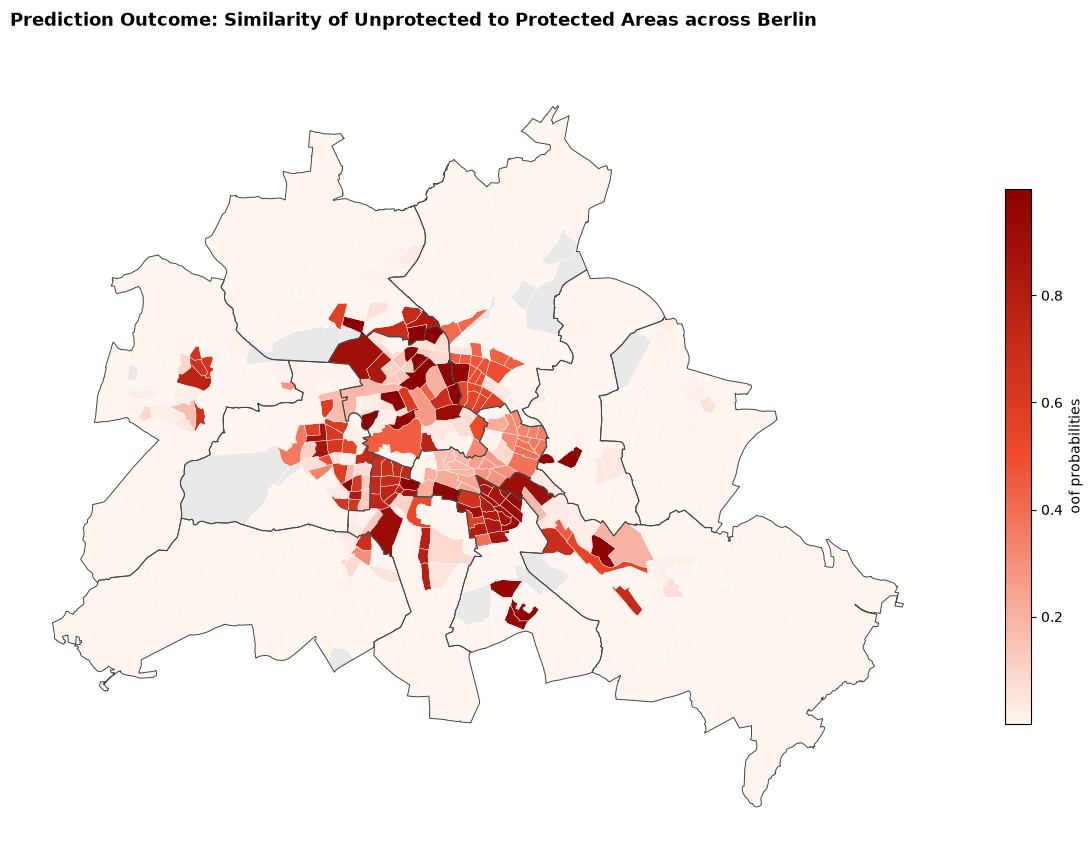

In [ ]:
#plot the watchlist map 
#which undesignated PLR most resemble designated ones?

red_cmap = LinearSegmentedColormap.from_list("kiez_red", ["#FFF5F0", "#EE4B2B", "#8B0000"])
fig, ax = plt.subplots(figsize=(12, 11))

#layer 1: all PLR as light grey base (so dropped + designated areas are visible, not holes)
plot_geo1.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.3)

#layer 2: designated PLR in a distinct neutral (already protected — not "urgent")
plot_geo1[plot_geo1["y_true"] == 1].plot(
    ax=ax, cmap=red_cmap, edgecolor="white", linewidth=0.3
)

#layer 3: undesignated PLR coloured (white -> red)
plot_geo1[undes1].plot(
    ax=ax, cmap=red_cmap, edgecolor="white", linewidth=0.3,
    legend=True, column="oof_prob", legend_kwds={"label": "oof probabilities",
                              "shrink": 0.5}
)

#Bezirk outlines so the weak-fold districts are locatable
gdf.dissolve("bez").boundary.plot(ax=ax, color="#444444", linewidth=0.7)

ax.set_title("Prediction Outcome: Similarity of Unprotected to Protected Areas across Berlin\n",
             fontsize=13, fontweight="bold", loc="left")
ax.axis("off")
plt.tight_layout()
plt.savefig("../../plots/Module2/M2_watchlist_plot.png", dpi=200, bbox_inches="tight")
plt.show()